# IN5437 — Assignment 1
## Question 11: Spatial Filtering and Frequency Response

**Name:** Benjamine  
**Index:** 258762A

Consider a 2D image $f(x, y)$ and filter $h(x, y)$ with filtered output:
$$g(x, y) = f(x, y) * h(x, y)$$

This question explores the relationship between spatial convolution and frequency-domain multiplication, and analyzes three common filters (box, Gaussian, Laplacian).

### Part (a): The Convolution Theorem

The Convolution Theorem says that if we convolve an image $f$ with a filter $h$ in the spatial domain, it is the same as multiplying their Fourier transforms in the frequency domain:

$$g(x, y) = f(x, y) * h(x, y)$$

$$G(u, v) = F(u, v) \cdot H(u, v)$$

where $F$, $G$, $H$ are the 2D Fourier transforms of $f$, $g$, $h$.

**What this means for us.** Every spatial filter we apply has a "frequency response" $H(u, v)$. When we filter an image, the frequency-domain view is simple: each frequency component of the image is scaled by the value of $H$ at that frequency.

- If $H$ is large at low frequencies and small at high frequencies → the filter is **low-pass** (smoothing, blurring).
- If $H$ is large at high frequencies and small at low frequencies → the filter is **high-pass** (edge enhancement).

So by looking at the shape of $H$, we can understand what a filter does without having to apply it to an image. This is the main link between the two ways of thinking about filtering.

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show_frequency_response(kernel, title, size=128):
    """Pad a kernel to size×size, take FFT, and display log magnitude."""
    # Pad the kernel to the analysis size
    padded = np.zeros((size, size), dtype=np.float64)
    kh, kw = kernel.shape
    padded[:kh, :kw] = kernel

    # 2D FFT, shift zero frequency to center
    fft = np.fft.fft2(padded)
    fft_shifted = np.fft.fftshift(fft)

    # Log magnitude for display (add small eps to avoid log(0))
    magnitude = np.log(np.abs(fft_shifted) + 1e-8)

    plt.figure(figsize=(5, 5))
    plt.imshow(magnitude, cmap='viridis')
    plt.title(f'{title}\nFrequency response (log magnitude)')
    plt.colorbar(fraction=0.046)
    plt.axis('off')
    plt.show()

    return magnitude

### Part (b): Frequency response of three filters

For each filter, we compute its 2D Fourier transform and visualize the magnitude. The center of each plot represents zero frequency (DC); frequency increases outward.

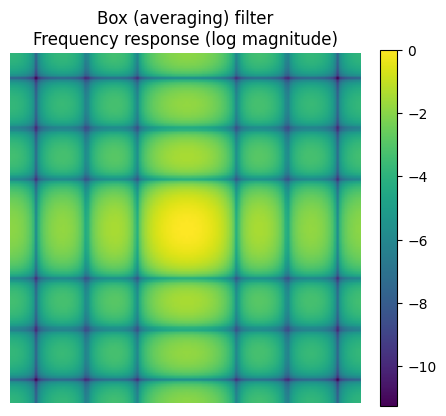

In [7]:
# Box (averaging) filter: 7x7 uniform kernel
box_kernel = np.ones((7, 7)) / 49
_ = show_frequency_response(box_kernel, 'Box (averaging) filter')

**Box filter.** In the spatial domain, this filter just replaces each pixel with the simple average of its neighbors. In the frequency domain, its response looks like a bright spot at the center with several rings fading outward (this pattern is called a *sinc* function in 1D). Because of these rings, the filter does not cleanly block high frequencies — some of them still pass through. That is why box-filtered images can show small "ringing" artifacts near sharp edges. It is a low-pass filter, but a noisy one.

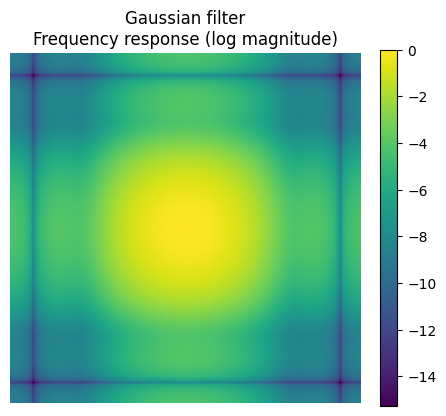

In [8]:
# Gaussian filter: 7x7 kernel with sigma = 1.5
size = 7
sigma = 1.5
ax_vals = np.arange(-(size//2), size//2 + 1)
xx, yy = np.meshgrid(ax_vals, ax_vals)
gauss_kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
gauss_kernel /= gauss_kernel.sum()
_ = show_frequency_response(gauss_kernel, 'Gaussian filter')

**Gaussian filter.** In the spatial domain, this is a weighted average where pixels closer to the center contribute more. In the frequency domain, the response is a single smooth bump that fades out as we move away from the center — no rings, no side-lobes. This is important: because the response goes down smoothly, the Gaussian filter attenuates high frequencies gradually without producing any ringing in the filtered image. This is why the Gaussian is the most commonly used smoothing filter.

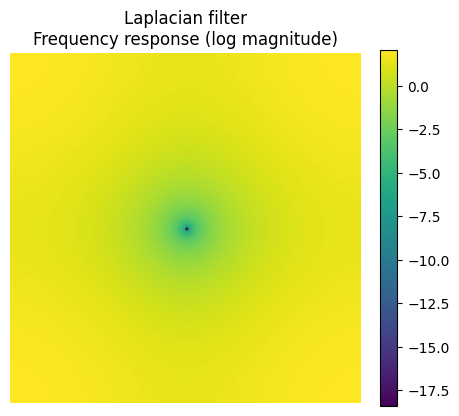

In [9]:
# Laplacian kernel (standard 3x3)
laplacian_kernel = np.array([[ 0, -1,  0],
                             [-1,  4, -1],
                             [ 0, -1,  0]], dtype=np.float64)
_ = show_frequency_response(laplacian_kernel, 'Laplacian filter')

**Laplacian filter.** Spatial: second-derivative operator — highlights regions of rapid intensity change (edges). Frequency: response is **zero at DC** (center) and **increases outward with frequency**. This is a **high-pass filter** — it blocks low-frequency (smooth) content and amplifies high-frequency (edge) content. This matches its spatial behavior: the Laplacian gives zero response in uniform regions and strong response at edges.

### Part (c): Why Gaussian avoids ringing (vs ideal low-pass)

An **ideal low-pass filter** is a filter that keeps every frequency below a cutoff completely (multiplied by 1) and blocks every frequency above it completely (multiplied by 0). In the frequency domain, this looks like a perfect circular disk.

**The problem.** When we convert that perfect disk back to the spatial domain (inverse Fourier transform), we get a function that has oscillating rings around its center. So when we use this filter on an image, those rings appear in the output as visible oscillations around sharp edges. This is called **ringing** (or the *Gibbs phenomenon*).

**Why Gaussian is different.** The Gaussian does not have any sharp cutoff. In the frequency domain it decays gradually from the center outwards, and in the spatial domain it is also a smooth bell with no rings. Because there are no oscillations in the filter itself, the filtered image also has no oscillations.

**Trade-off.** The ideal filter perfectly removes everything above the cutoff but produces ringing. The Gaussian is a softer filter — it attenuates some frequencies that we would like to keep, but it does not create ringing artifacts. In most practical image processing situations, avoiding ringing is more important, which is why Gaussian is preferred.

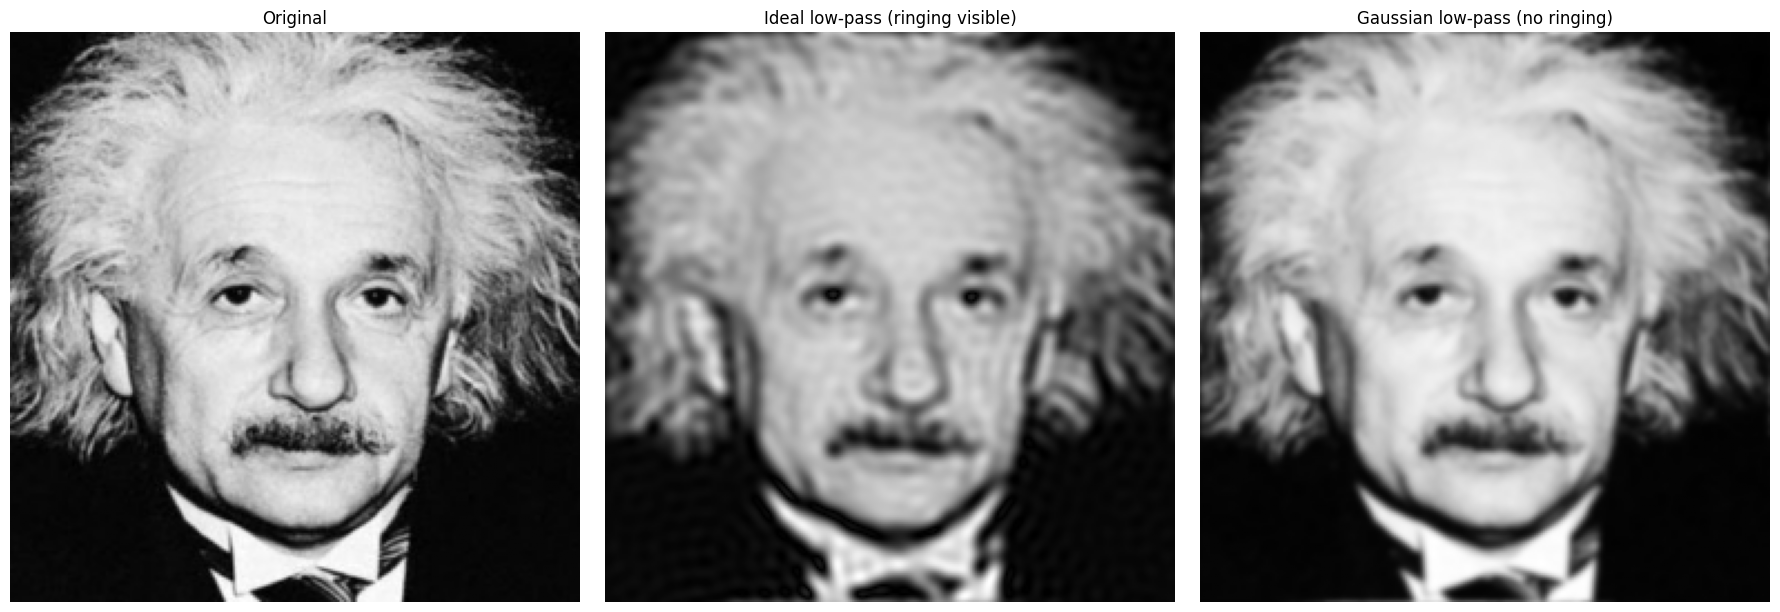

In [10]:
# Demonstrate ringing: apply an ideal low-pass filter and a Gaussian, show the difference
img = cv.imread('../images/einstein.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "File could not be read. Check the path."
img = cv.resize(img, (256, 256))

# FFT of image
F = np.fft.fftshift(np.fft.fft2(img))

# Ideal low-pass filter (circular mask)
h, w = F.shape
cx, cy = w // 2, h // 2
radius = 30
Y, X = np.ogrid[:h, :w]
mask_ideal = ((X - cx)**2 + (Y - cy)**2 <= radius**2).astype(np.float32)

# Gaussian low-pass filter (same effective cutoff)
sigma_f = 30
mask_gauss = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma_f**2))

# Apply both filters in the frequency domain, invert
img_ideal = np.abs(np.fft.ifft2(np.fft.ifftshift(F * mask_ideal)))
img_gauss = np.abs(np.fft.ifft2(np.fft.ifftshift(F * mask_gauss)))

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img, cmap='gray');        ax[0].set_title('Original');                       ax[0].axis('off')
ax[1].imshow(img_ideal, cmap='gray');  ax[1].set_title('Ideal low-pass (ringing visible)'); ax[1].axis('off')
ax[2].imshow(img_gauss, cmap='gray');  ax[2].set_title('Gaussian low-pass (no ringing)');   ax[2].axis('off')
plt.tight_layout()
plt.show()

### Part (d): Which filter is most suitable for high-frequency noise?

**The problem.** The image has high-frequency noise — random fluctuations that show up as bright and dark speckles in the high-frequency part of the spectrum.

**Which filter?** Among the three filters, the **Gaussian filter** is the best choice.

**Frequency-domain reasoning.** High-frequency noise sits in the outer regions of the frequency spectrum. To reduce it, we need a **low-pass filter** that keeps the low frequencies (the main image content) and reduces the high frequencies (the noise).
- The Gaussian is a low-pass filter with a smooth response — it reduces noise gradually without any ringing.
- The box filter is also low-pass, but its frequency response has side-lobes, so it lets some noise pass through and can introduce mild ringing.
- The Laplacian is a **high-pass** filter — it would actually amplify the noise instead of removing it, which is the opposite of what we want.

**Spatial-domain reasoning.** The Gaussian replaces each pixel with a smooth weighted average of its neighbors. Because noise values are random, averaging with Gaussian weights cancels them out, while the true signal (which varies slowly over a neighborhood) is mostly preserved. The box filter averages too, but uniformly — so it is slightly less effective and can leave small artifacts. The Laplacian highlights change, which would amplify noise rather than remove it.

**Conclusion.** The Gaussian filter is the suitable choice because it is a clean low-pass filter in both domains: in frequency it cleanly attenuates the high-frequency noise, and in space it produces a smooth, artifact-free output.

**Note.** This reasoning applies to high-frequency *Gaussian / random* noise. For **salt-and-pepper** (impulse) noise, as we saw in Q8, the **median filter** works better than Gaussian because it ignores outliers rather than averaging them.